# Visualizing fidelity instabilities in temporal graph models

This notebook generates paper-ready visualizations for the three instability mechanisms described in the note:

1. **Aggregation normalization shift**
2. **Sequential memory drift** in a GRU-style memory
3. **Subgraph topology collapse**

The GRU section is deliberately the most detailed. All figures are exported as vector PDFs using the requested palette:

- `eventblue = blue!65!black`
- `snapshotorange = orange!85!black`
- `edgegray = black!55`

All generated files are saved into the local `figures/` directory next to this notebook.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from generate_instability_figures import (
    OUTDIR,
    EVENTBLUE,
    SNAPSHOTORANGE,
    EDGEGRAY,
    PALEBLUE,
    PALEORANGE,
    make_gru_memory_drift_figure,
    make_normalization_shift_figure,
    make_subgraph_topology_figure,
    make_summary_triptych,
    build_gru_case,
)

OUTDIR.mkdir(exist_ok=True, parents=True)
OUTDIR


PosixPath('/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures')

## Palette preview

A quick swatch so the exported PDFs visibly match the requested colors before generating the figures.


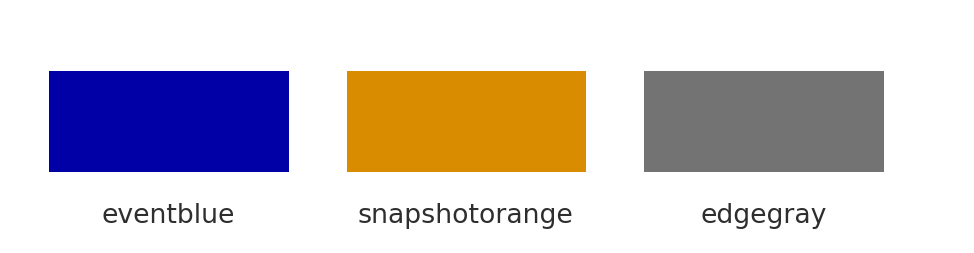

In [2]:
fig, ax = plt.subplots(figsize=(7.6, 1.8))
ax.axis("off")
colors = [
    (EVENTBLUE, "eventblue"),
    (SNAPSHOTORANGE, "snapshotorange"),
    (EDGEGRAY, "edgegray"),
]
for i, (color, label) in enumerate(colors):
    ax.add_patch(Rectangle((i * 1.8, 0.35), 1.45, 0.55, facecolor=color, edgecolor="none"))
    ax.text(i * 1.8 + 0.72, 0.12, label, ha="center", va="center", fontsize=12)
ax.set_xlim(-0.2, 5.5)
ax.set_ylim(0, 1.2)
plt.show()


## 1. Sequential memory drift in a GRU

The GRU instability visuals are now exported as **separate figures** so each mechanism is readable on its own.

This section now includes:

- an **original temporal neighborhood graph** (before pruning),
- an **input-setting graph** (temporal neighborhood to ordered messages),
- an **unrolled GRU sequence view** with a clearly marked shared start and divergence point,
- the **hidden-state trajectory** in memory space,
- the **state-drift curve** over event index, and
- a representative **update-gate regime shift** after pruning one event.

In [3]:
case = build_gru_case()
full_states = case["full"]["states"]
skipped_states = case["skipped"]["states"]
drift = np.linalg.norm(full_states - skipped_states, axis=1)
print(f"Removed event index: {case['remove_idx']}")
print(f"Max state drift:     {drift.max():.3f}")
print(f"Final state drift:   {drift[-1]:.3f}")


Removed event index: 6
Max state drift:     2.631
Final state drift:   2.631


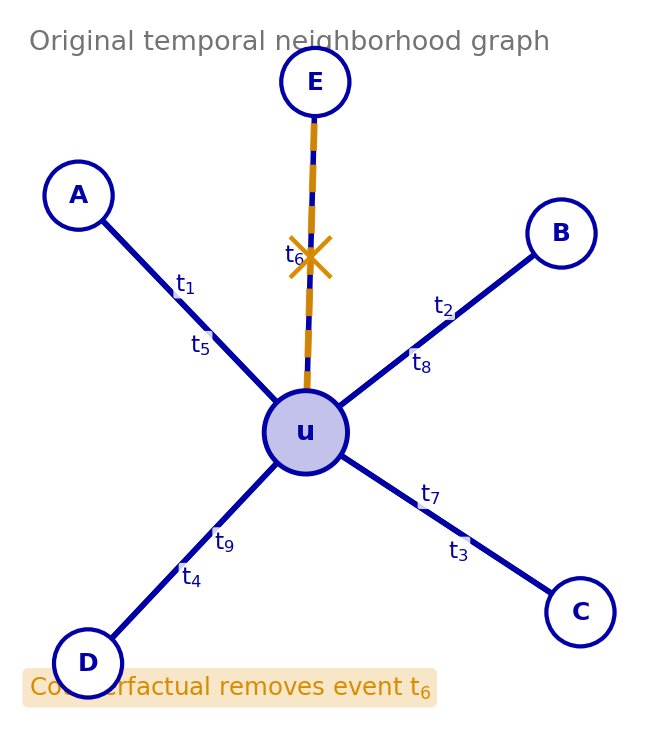

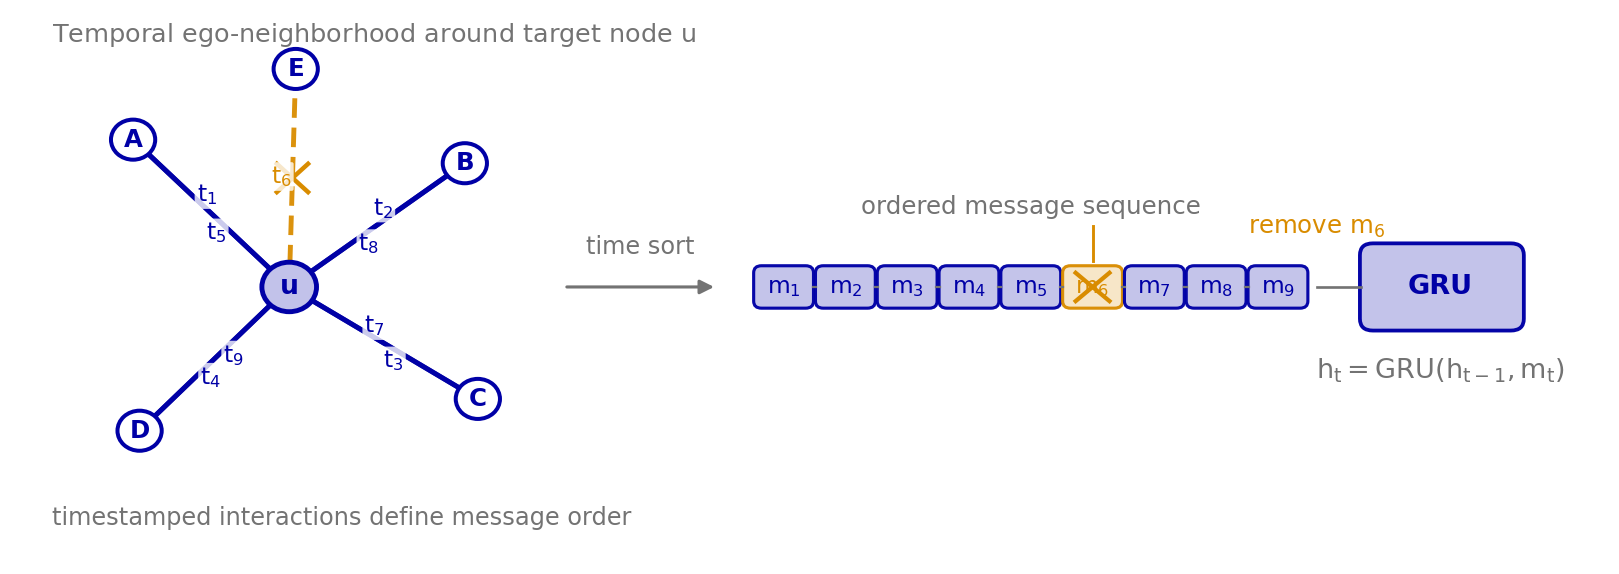

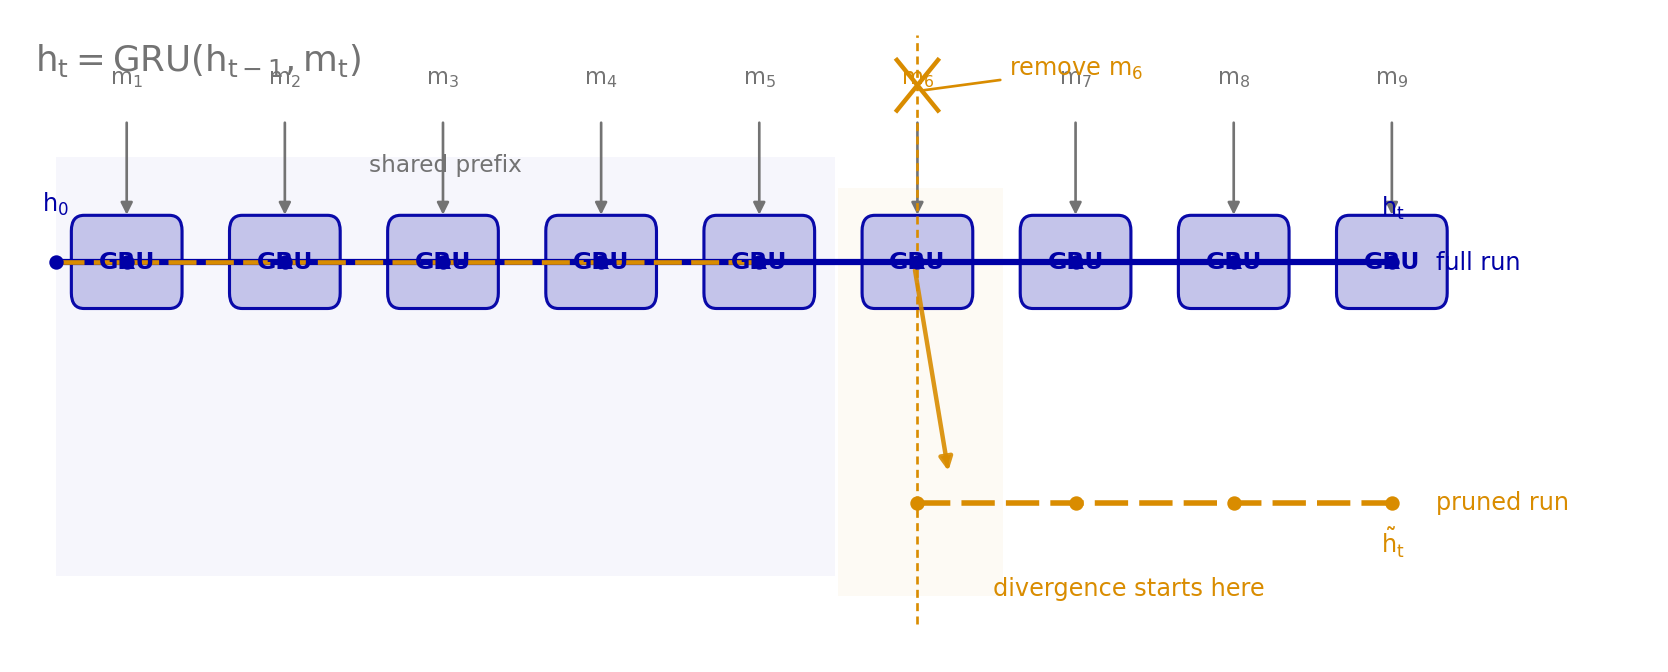

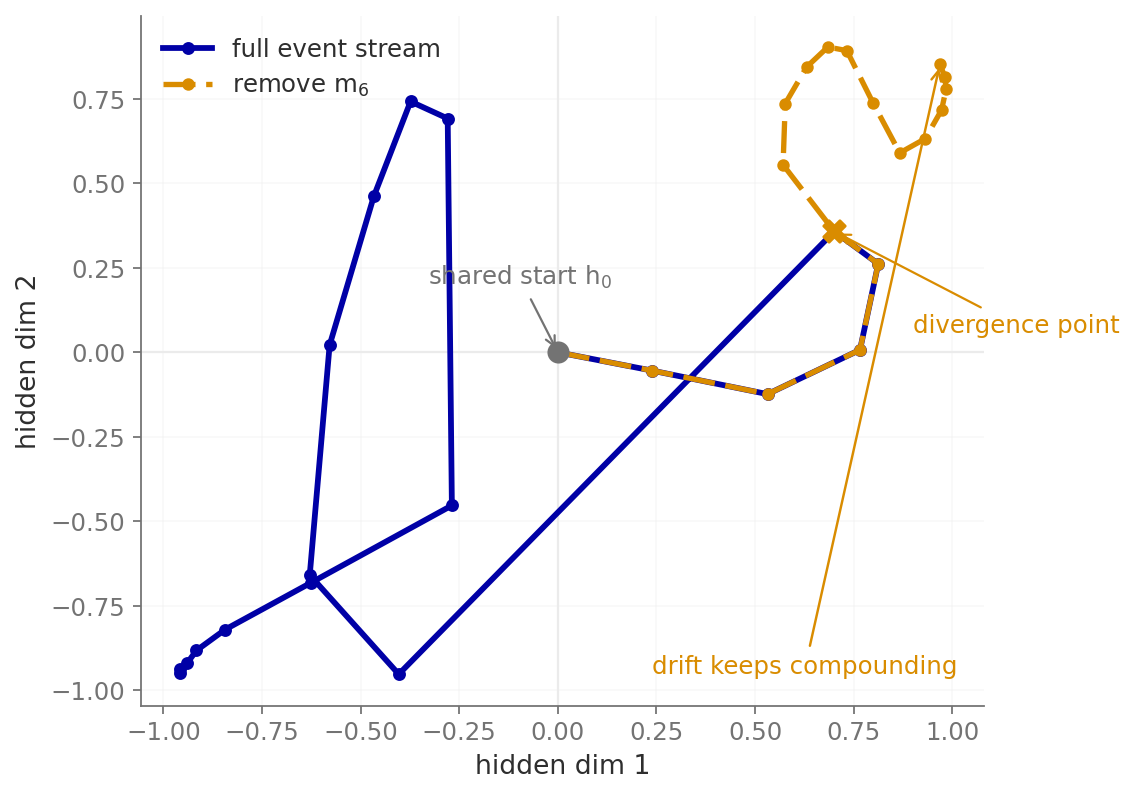

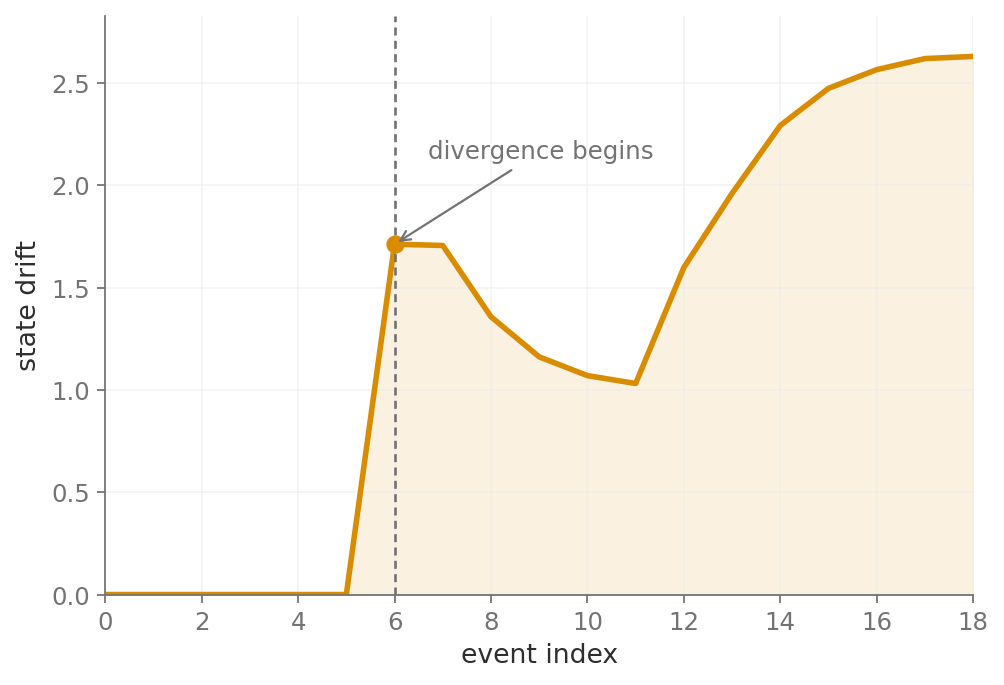

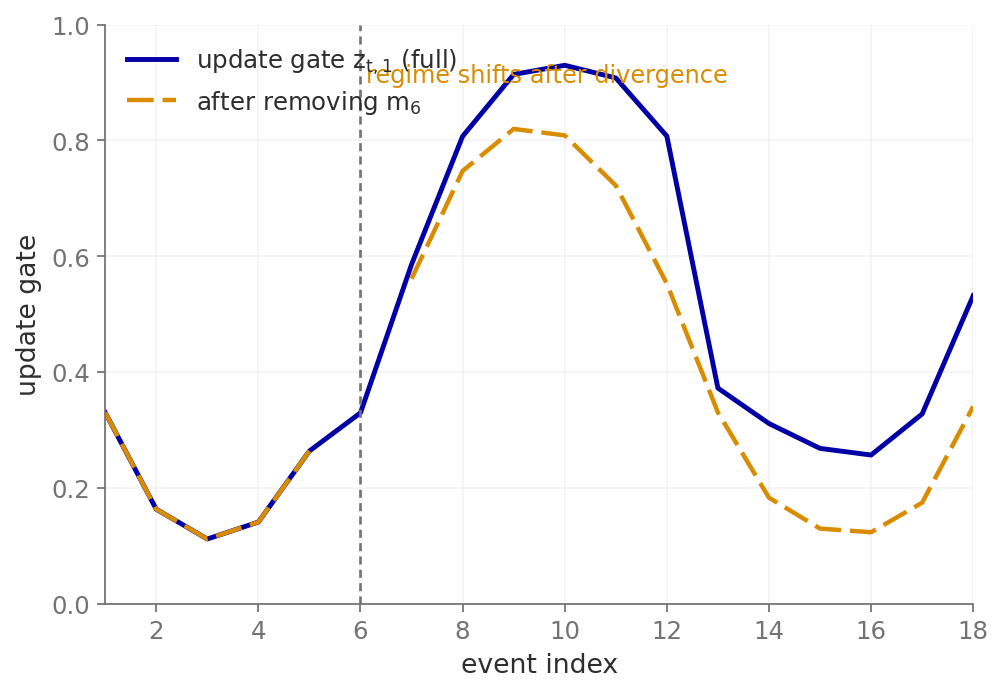

GRU figures:
 - /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/01a0_gru_original_graph.pdf
 - /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/01a_gru_input_setting.pdf
 - /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/01b_gru_sequence_divergence.pdf
 - /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/01c_gru_hidden_trajectory.pdf
 - /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/01d_gru_state_drift_curve.pdf
 - /Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/01e_gru_gate_regime_shift.pdf


In [4]:
path_gru = make_gru_memory_drift_figure()
plt.show()
print("GRU figures:")
for p in path_gru:
    print(" -", p)


## 2. Aggregation normalization shift

This section now shows four normalization figures:

- **mean aggregation** changes because the denominator shrinks when events are removed,
- **attention-based aggregation** renormalizes the remaining weights after pruning,
- **mask sensitivity (part 1)** shows feature shift for each pruning mask on the **same target prediction**, and
- **mask sensitivity (part 2)** shows the resulting logits and whether each mask flips the prediction (crosses 0).


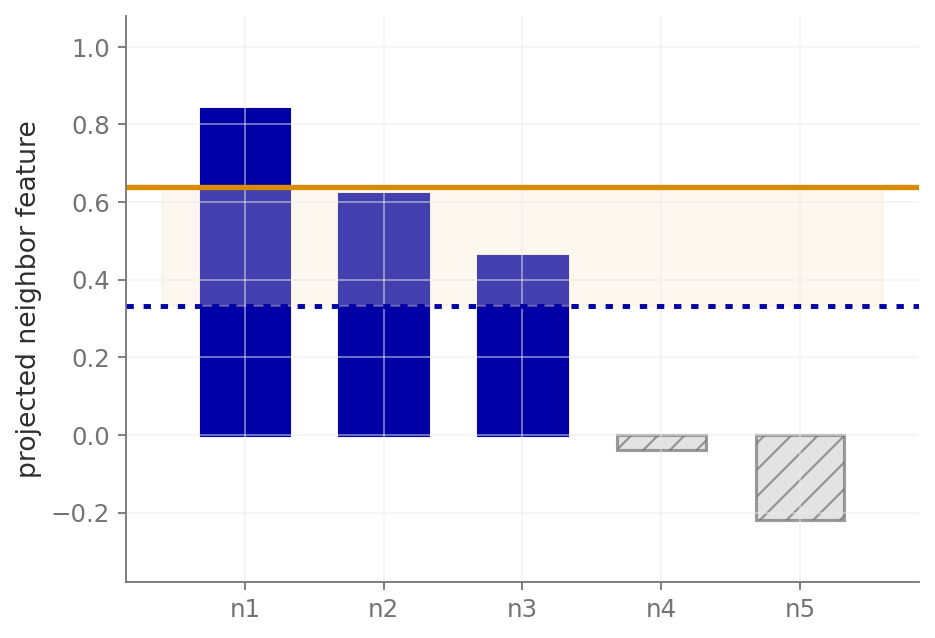

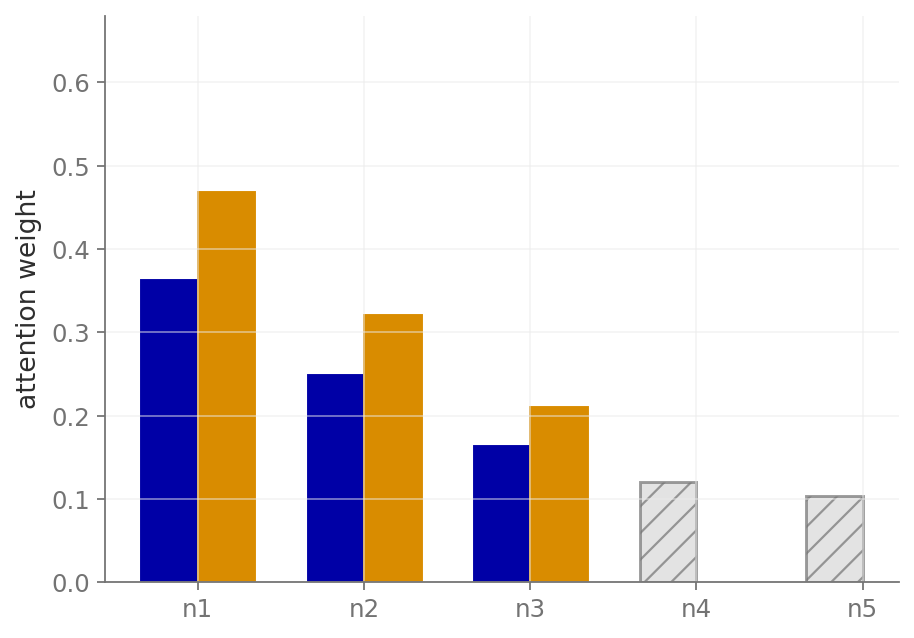

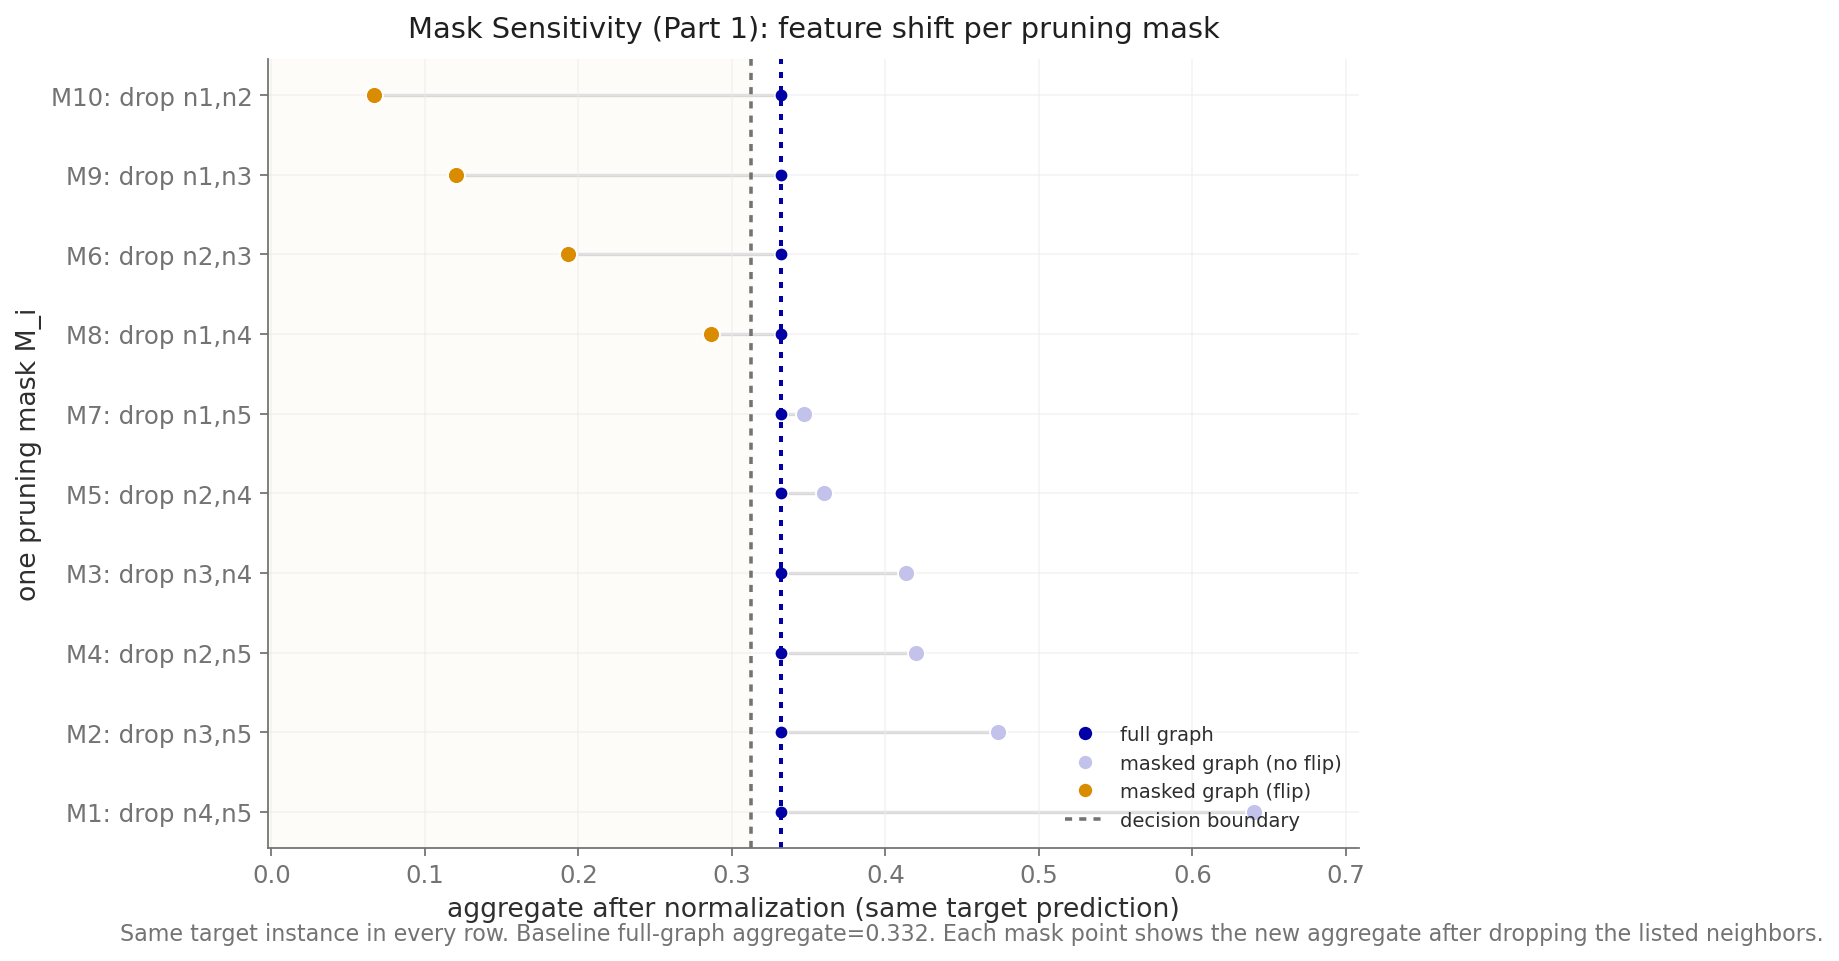

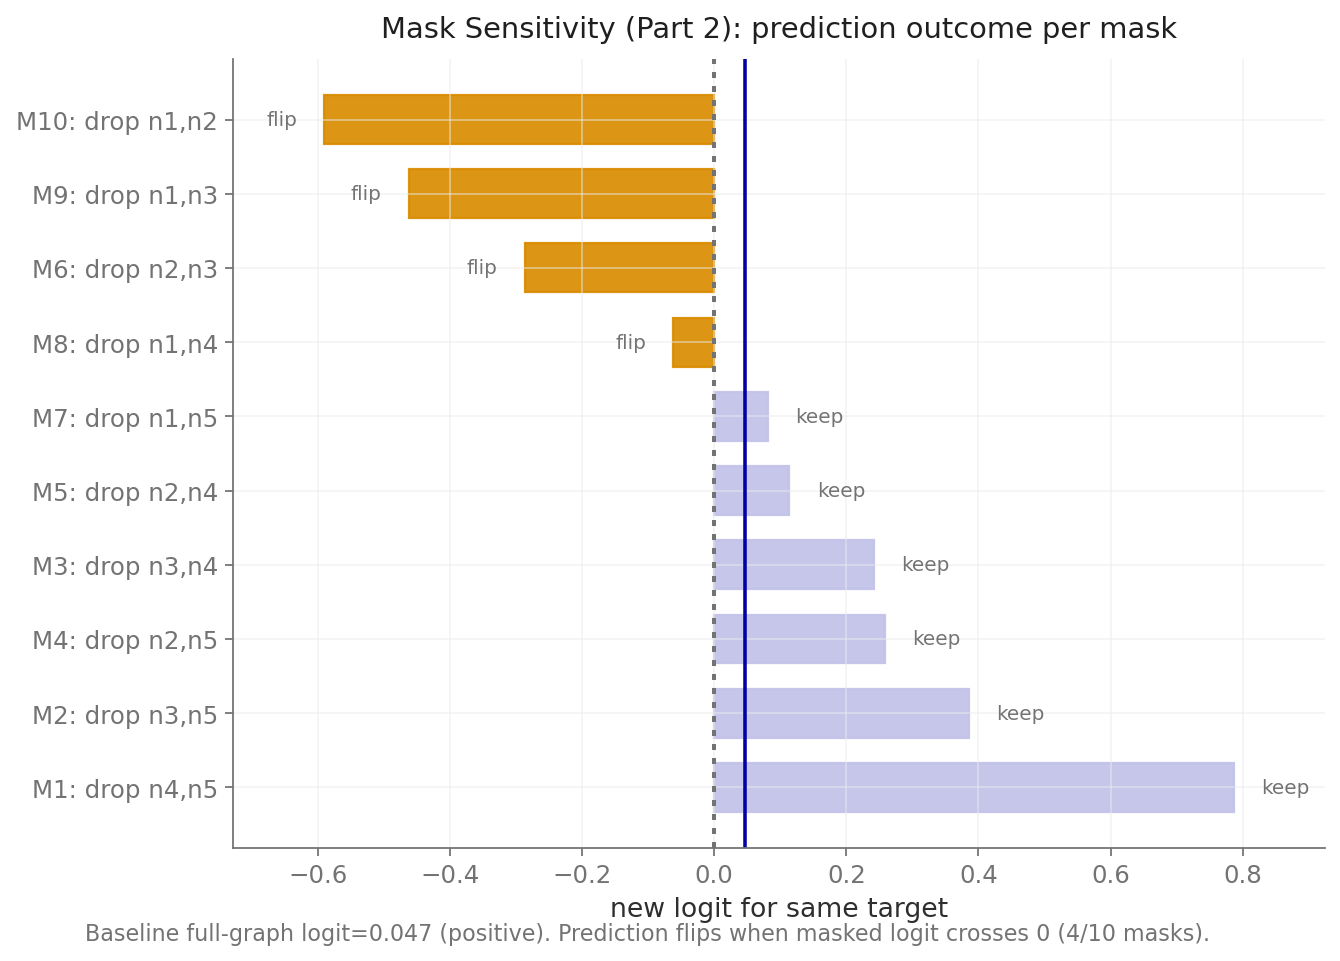

[PosixPath('/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/02a_normalization_mean_shift.pdf'), PosixPath('/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/02b_normalization_attention_shift.pdf'), PosixPath('/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/02c_normalization_mask_shift.pdf'), PosixPath('/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/02d_normalization_mask_prediction_flip.pdf')]


In [5]:
path_norm = make_normalization_shift_figure()
plt.show()
print(path_norm)


## 3. Subgraph topology collapse

Sufficiency-style evaluation often keeps only an explanation subgraph. That can change:

- degree profiles,
- connectivity and component structure, and
- temporal density through larger event gaps.

The figure below compares a full temporal neighborhood with its explanation-induced subgraph.


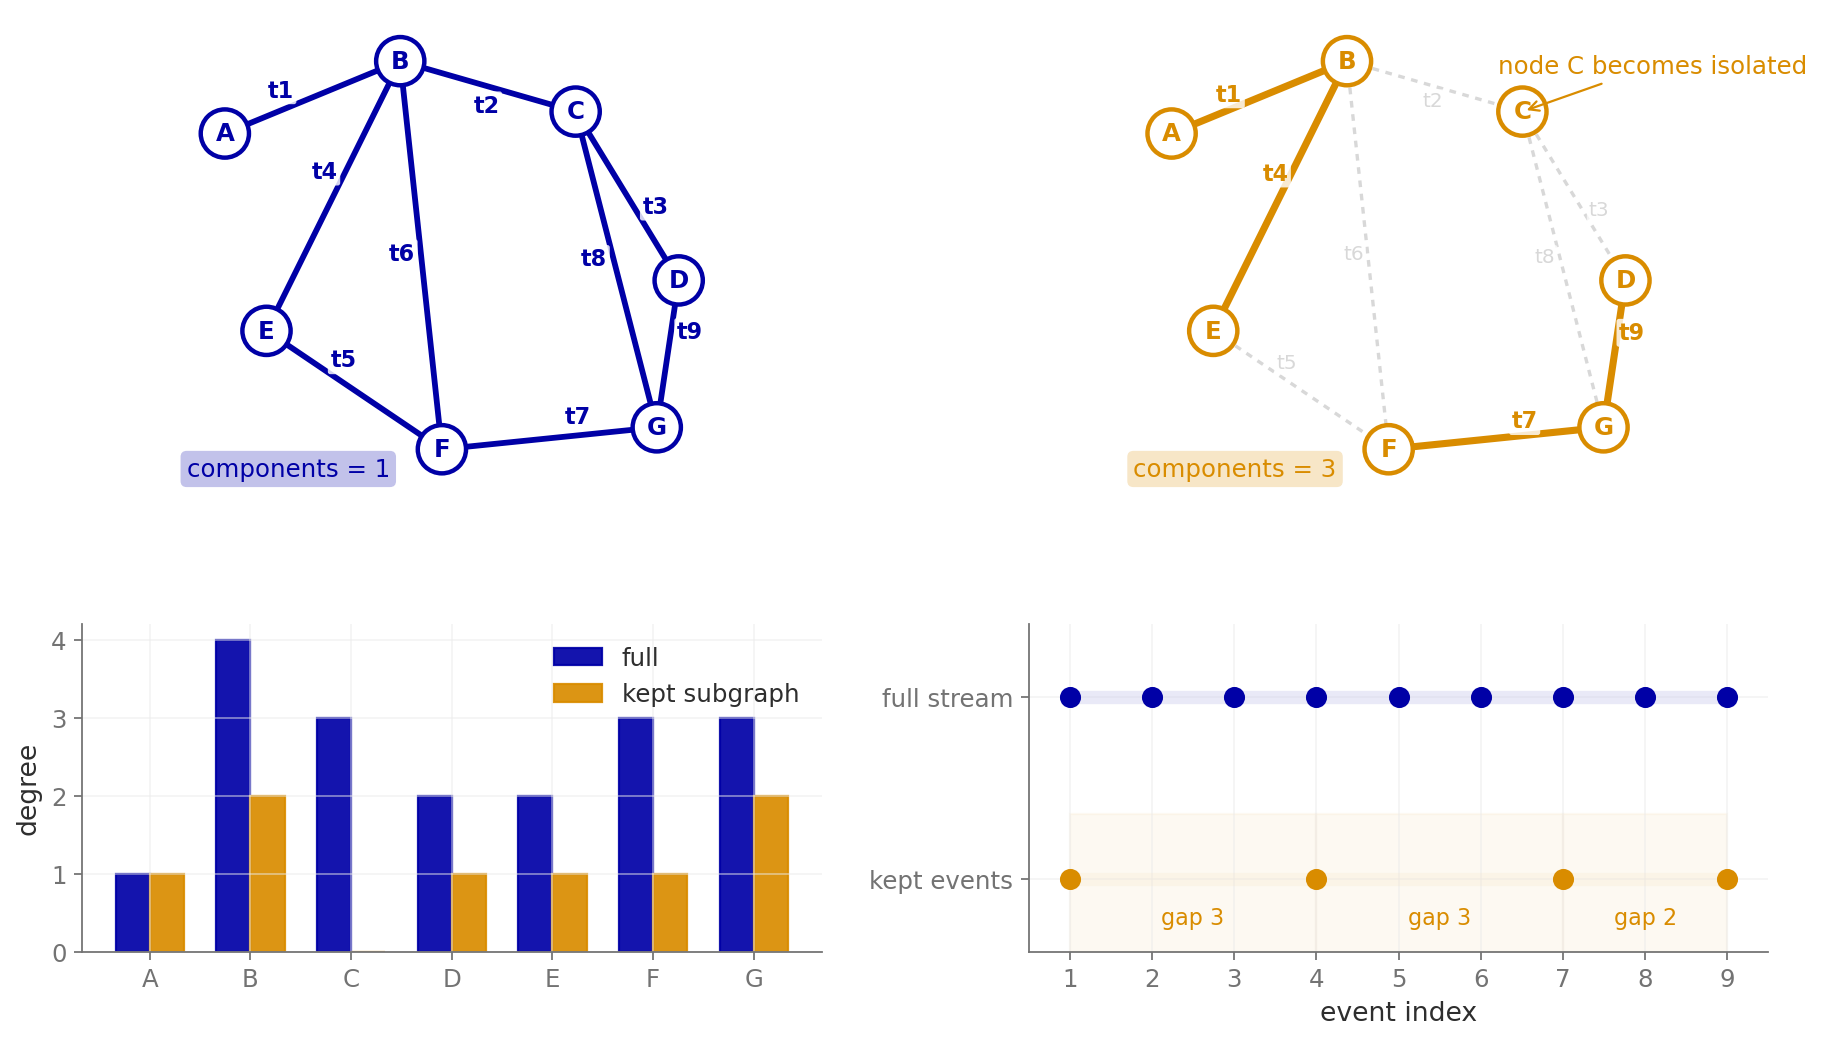

/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/03_subgraph_topology_collapse.pdf


In [6]:
path_topo = make_subgraph_topology_figure()
plt.show()
print(path_topo)


## 4. Compact overview

A one-page summary that can be dropped into slides or an appendix.


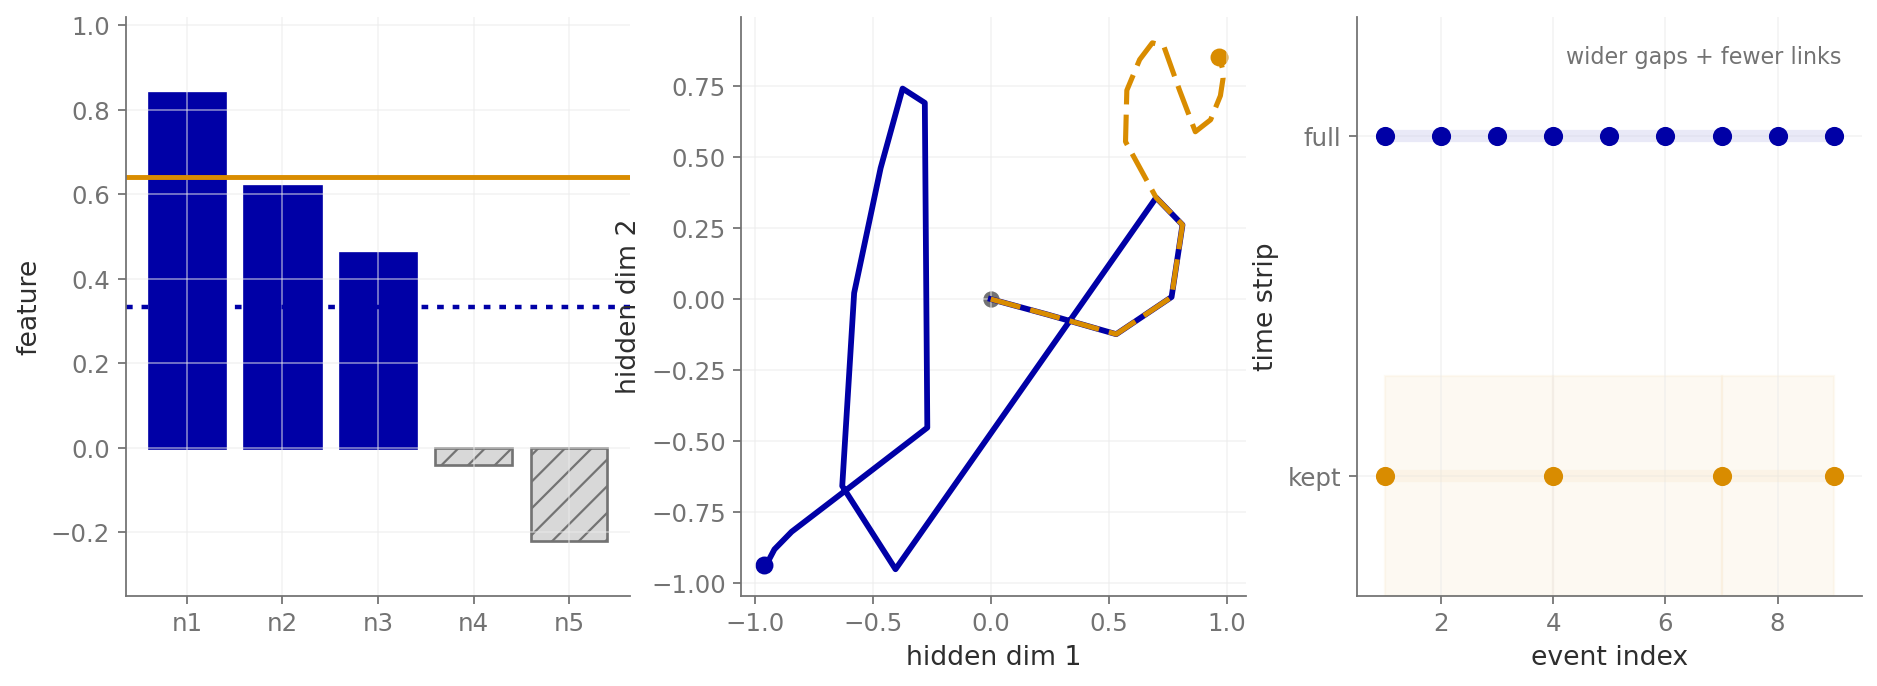

/Users/juliawenkmann/Documents/CodingProjects/master_thesis/time_to_explain_official/part_III/temporal_instability_viz/figures/04_three_instabilities_overview.pdf


In [7]:
path_summary = make_summary_triptych()
plt.show()
print(path_summary)


## Exported files

The notebook writes vector PDFs into `figures/`. The cell below lists the final artifacts.


In [8]:
for path in sorted(OUTDIR.glob("*.pdf")):
    print(path.name)


01a0_gru_original_graph.pdf
01a_gru_input_setting.pdf
01b_gru_sequence_divergence.pdf
01c_gru_hidden_trajectory.pdf
01d_gru_state_drift_curve.pdf
01e_gru_gate_regime_shift.pdf
02a_normalization_mean_shift.pdf
02b_normalization_attention_shift.pdf
02c_normalization_mask_instability.pdf
02c_normalization_mask_shift.pdf
02d_normalization_mask_prediction_flip.pdf
03_subgraph_topology_collapse.pdf
03a_topology_full_neighborhood.pdf
03b_topology_explanation_subgraph.pdf
03c_topology_degree_profile.pdf
03d_topology_temporal_density.pdf
04_three_instabilities_overview.pdf
